# Chen Q2

## part a

Text(0, 0.5, 'Error')

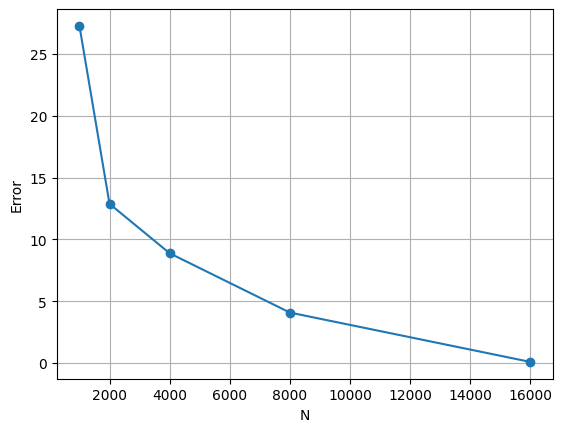

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = [ 1000, 2000, 4000, 8000, 16000]
E = [ 27.2778, 12.8778,8.8778, 4.0778, 0.0822999 ]
plt.plot(N, E, '-o')
plt.grid(True)
plt.xlabel("N")
plt.ylabel("Error")

# part c

Text(0, 0.5, 'Error')

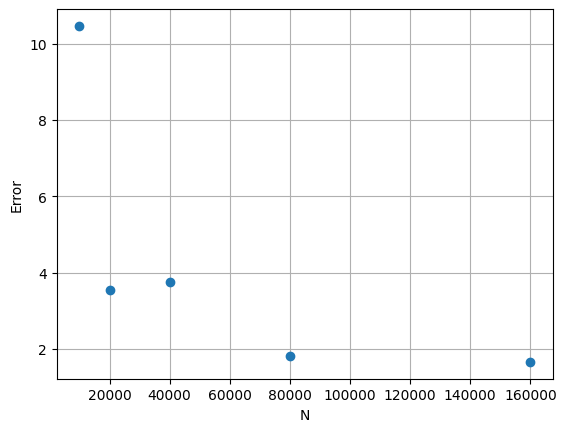

In [2]:
import numpy as np
import matplotlib.pyplot as plt

N = [ 10000, 20000, 40000, 80000, 160000]
E = [ 10.4642, 3.53582, 3.74418, 1.80418, 1.65582 ]
plt.plot(N, E, 'o')
plt.grid(True)
plt.xlabel("N")
plt.ylabel("Error")

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Function to approximate: f(x) = (tanh(10x - 5) - tanh(10x + 5))/2
def f(x):
    return (np.tanh(10 * x - 5) - np.tanh(10 * x + 5)) / 2

# Calculate Legendre polynomial values for a given x up to order n
def legendre_values(x, n):
    values = [legendre(i, x) for i in range(n + 1)]
    return values

# Legendre polynomial evaluation using recurrence relation
def legendre(n, x):
    if n == 0:
        return 1
    elif n == 1:
        return x
    else:
        P_n_minus_1 = np.ones_like(x)
        P_n_minus_2 = x
        P_n = np.zeros_like(x)
        for k in range(2, n + 1):
            P_n = ((2 * k - 1) * x * P_n_minus_2 - (k - 1) * P_n_minus_1) / k
            P_n_minus_1, P_n_minus_2 = P_n, P_n_minus_1
        return P_n

# Numerical quadrature using the composite midpoint rule
def numerical_quadrature(f, a, b, N):
    h = (b - a) / N
    x_vals = np.linspace(a + h/2, b - h/2, N)
    sum_val = np.sum(f(x_vals[:, np.newaxis]))
    integral = h * sum_val
    return integral

# Number of Legendre polynomials
n = 4

# Coefficients c0, c1, ..., cn
coefficients = [0] * (n + 1)

# Calculate the coefficients
for i in range(n + 1):
    integrand = lambda x: f(x) * legendre_values(x, i)
    coefficients[i] = numerical_quadrature(integrand, -1, 1, 1000)

# Create an array of x values for plotting
x_vals = np.linspace(-1, 1, 1000)

# Calculate the corresponding f(x) and p4(x) values
f_vals = f(x_vals)
p4_vals = legendre(4,x_vals)
diff_vals = np.abs(f_vals - p4_vals)

# Plot f(x) and p4(x)
plt.plot(x_vals, f_vals, label='f(x)')
plt.plot(x_vals, p4_vals, label='p4(x)')
plt.plot(x_vals, diff_vals, label='|f(x) - p4(x)|')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Function f(x) and Legendre polynomial approximation p4(x)')
plt.legend()
plt.show()


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [4]:
from scipy.special import legendre
legendre(3)

poly1d([ 2.5,  0. , -1.5,  0. ])

## Wang parallel Programming

### OpenMP

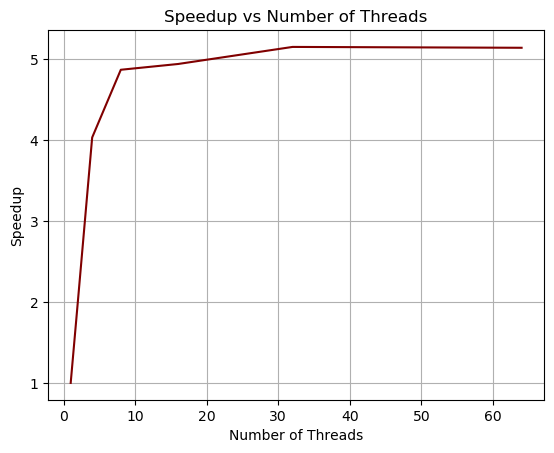

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n = [1, 2, 4, 8, 16, 32, 64]
time = [2.14018, 1.06769, 0.530781, 0.439563, 0.43322, 0.415484, 0.416332]
s = []
for i in range(len(time)):
    s.append(time[0] / time[i])

plt.plot(n, s, 'maroon')
plt.xlabel('Number of Threads')
plt.ylabel('Speedup')
plt.grid(True)
plt.title('Speedup vs Number of Threads')
plt.show()
